In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# We display full columns as our dataset has 28 columns
pd.set_option('display.max_columns', None)


# How Cinema Has Changed Over the Years?

### 1. Introduction

In this notebook, we will perform an exploratory data analysis on a movie dataset (from TMDB) to understand how cinema has evolved over time. We will examine trends in movie production, runtime, budget, revenue, ratings, genres, and languages across decades.

Our goal is to uncover patterns in the data that help explain how cinema has evolved over time.

In [2]:
df_movies = pd.read_csv('TMDB_all_movies.csv')
df_movies.head()


,id,title,vote_average,vote_count,status,release_date,revenue,runtime,budget,imdb_id,original_language,original_title,overview,popularity,tagline,genres,production_companies,production_countries,spoken_languages,cast,director,director_of_photography,writers,producers,music_composer,imdb_rating,imdb_votes,poster_path
0,2,Ariel,7.1,367.0,Released,1988-10-21,0.0,73.0,0.0,tt0094675,fi,Ariel,A Finnish man goes to the city to find a job a...,4.1418,NaN,"Comedy, Drama, Romance, Crime",Villealfa Filmproductions,Finland,suomi,"Tarja Keinänen, Marja Packalén, Kari Helaseppä...",Aki Kaurismäki,Timo Salminen,Aki Kaurismäki,Aki Kaurismäki,NaN,7.4,9661.0,/ojDg0PGvs6R9xYFodRct2kdI6wC.jpg
1,3,Shadows in Paradise,7.3,430.0,Released,1986-10-17,0.0,74.0,0.0,tt0092149,fi,Varjoja paratiisissa,"Nikander, a rubbish collector and would-be ent...",5.4837,NaN,"Comedy, Drama, Romance",Villealfa Filmproductions,Finland,"svenska, suomi, English","Haije Alanoja, Mari Rantasila, Matti Pellonpää...",Aki Kaurismäki,Timo Salminen,Aki Kaurismäki,Mika Kaurismäki,NaN,7.4,8538.0,/nj01hspawPof0mJmlgfjuLyJuRN.jpg
2,5,Four Rooms,5.9,2804.0,Released,1995-12-09,4257354.0,98.0,4000000.0,tt0113101,en,Four Rooms,It's Ted the Bellhop's first night on the job....,2.2654,Twelve outrageous guests. Four scandalous requ...,Comedy,"Miramax, A Band Apart",United States of America,English,"Marisa Tomei, Kimberly Blair, Madonna, Tamlyn ...","Quentin Tarantino, Robert Rodriguez, Alexandre...","Guillermo Navarro, Andrzej Sekula, Phil Parmet...","Quentin Tarantino, Robert Rodriguez, Alexandre...","Lawrence Bender, Quentin Tarantino, Alexandre ...",Combustible Edison,6.7,116584.0,/75aHn1NOYXh4M7L5shoeQ6NGykP.jpg
3,6,Judgment Night,6.5,360.0,Released,1993-10-15,12136938.0,109.0,21000000.0,tt0107286,en,Judgment Night,"Four young friends, while taking a shortcut en...",4.2730,Don't move. Don't whisper. Don't even breathe.,"Action, Crime, Thriller","Largo Entertainment, JVC, Universal Pictures",United States of America,English,"Doug Wert, Angela Alvarado, Everlast, Sean O'G...",Stephen Hopkins,Peter Levy,"Lewis Colick, Jere Cunningham","Marilyn Vance, Gene Levy, Lloyd Segan",Alan Silvestri,6.6,20925.0,/3rvvpS9YPM5HB2f4HYiNiJVtdam.jpg
4,8,Life in Loops (A Megacities RMX),7.2,30.0,Released,2006-01-01,0.0,80.0,42000.0,tt0825671,en,Life in Loops (A Megacities RMX),Timo Novotny labels his new project an experim...,2.2585,A Megacities remix.,Documentary,inLoops,Austria,"English, हिन्दी, 日本語, Pусский, Español",NaN,Timo Novotny,Wolfgang Thaler,"Timo Novotny, Michael Glawogger","Timo Novotny, Ulrich Gehmacher",NaN,8.1,285.0,/7ln81BRnPR2wqxuITZxEciCe1lc.jpg


In [3]:
print("Data types:")
print(df_movies.info())

Data types:
<class 'pandas.DataFrame'>
RangeIndex: 1169605 entries, 0 to 1169604
Data columns (total 28 columns):
 #   Column                   Non-Null Count    Dtype  
---  ------                   --------------    -----  
 0   id                       1169605 non-null  int64  
 1   title                    1169595 non-null  str    
 2   vote_average             1169605 non-null  float64
 3   vote_count               1169605 non-null  float64
 4   status                   1169605 non-null  str    
 5   release_date             1048373 non-null  str    
 6   revenue                  1169605 non-null  float64
 7   runtime                  1169605 non-null  float64
 8   budget                   1169605 non-null  float64
 9   imdb_id                  657324 non-null   str    
 10  original_language        1169605 non-null  str    
 11  original_title           1169596 non-null  str    
 12  overview                 991137 non-null   str    
 13  popularity               1169605 non-null

#### 1.1 Checking missing values

In [4]:
missing_count = df_movies.isna().sum()
missing_percentage = missing_count / len(df_movies) * 100

missing_df = pd.DataFrame({"missing_values": missing_count, "missing_percentage": missing_percentage})
missing_df = missing_df[missing_df["missing_values"] > 0]
missing_df.sort_values(by="missing_percentage", ascending=False)

,missing_values,missing_percentage
music_composer,1038027,88.750219
tagline,992746,84.878741
director_of_photography,856672,73.244557
producers,771611,65.971931
imdb_votes,706265,60.384916
imdb_rating,706265,60.384916
production_companies,606469,51.852463
writers,578353,49.448575
imdb_id,512281,43.799488
production_countries,433957,37.102868


Budget, revenue, runtime, vote_count, vote_average, popularity are 0 when not specified, hence we will handle these separately.

In [5]:
zero_vote_average = (df_movies['vote_average'] == 0).sum()
zero_vote_count = (df_movies['vote_count'] == 0).sum()
zero_revenue = (df_movies['revenue'] == 0).sum()
zero_runtime = (df_movies['runtime'] == 0).sum()
zero_budget = (df_movies['budget'] == 0).sum()
zero_popularity = (df_movies['popularity'] == 0).sum()

zero_percent_vote_average = zero_vote_average / len(df_movies) * 100
zero_percent_vote_count = zero_vote_count / len(df_movies) * 100
zero_percent_revenue = zero_revenue / len(df_movies) * 100
zero_percent_runtime = zero_runtime / len(df_movies) * 100
zero_percent_budget = zero_budget / len(df_movies) * 100
zero_percent_popularity = zero_popularity / len(df_movies) * 100

zeros_df = pd.DataFrame({
    'missing_values': [
        zero_vote_average,
        zero_vote_count,
        zero_revenue,
        zero_runtime,
        zero_budget,
        zero_popularity
    ],
    'missing_percentage': [
        zero_percent_vote_average,
        zero_percent_vote_count,
        zero_percent_revenue,
        zero_percent_runtime,
        zero_percent_budget,
        zero_percent_popularity
    ]
}, index=[
    'vote_average',
    'vote_count',
    'revenue',
    'runtime',
    'budget',
    'popularity'
])

zeros_df

,missing_values,missing_percentage
vote_average,779148,66.616336
vote_count,778656,66.574271
revenue,1142597,97.690844
runtime,268914,22.991865
budget,1093142,93.462494
popularity,4007,0.342594


Exploring the dataset reveals a significant amount of missing information across several variables.

Production-related metadata such as **music composer (88.7% missing)**, **tagline (84.9%)**, and **director of photography (73.2%)** is often unavailable. Financial variables also contain many zero values (**93.5% for budget** and **97.7% for revenue**), which likely correspond to missing historical records rather than actual values.

Since this dataset spans a long period of cinema history, older films tend to have less complete documentation.

In our analysis, we will primarily rely on variables that are widely available across the dataset, such as **release dates, genres, cast, directors**, since they contain the most complete information. However, we will still analyze other variables, including financial data, ratings, whenever sufficient data is available in order to explore broader trends in cinema over time.

#### 1.2 Data Cleaning and Preprocessing

To avoid biasing the analysis, we replace these zero values we saw earlier with **NaN** so they are treated as missing data.

In [6]:
cols = ['budget', 'revenue', 'runtime', 'vote_count', 'vote_average', 'popularity']

df_movies[cols] = df_movies[cols].replace(0, np.nan)

To make date more interpretable, we keep only the year of release of the movies.

In [7]:
df_movies['release_date'] = pd.to_datetime(df_movies['release_date'], errors='coerce')
df_movies['year'] = df_movies['release_date'].dt.year

Some columns in the dataset (**genres, production_companies, production_countries, spoken_languages, cast, director, director_of_photography, writers, producers, and music_composer**) contain multiple values stored as **comma-separated strings**.

To facilitate analysis and visualization, we convert these strings into **lists**. It will allows us to treat each element individually (we could get for example each genre or actor), making it easier to compute frequencies and study trends over time.

In [8]:
cols = [
    "genres",
    "production_companies",
    "production_countries",
    "spoken_languages",
    "cast",
    "director",
    "director_of_photography",
    "writers",
    "producers",
    "music_composer"
]

for col in cols:
    df_movies[col] = df_movies[col].fillna("").apply(lambda x: [i.strip() for i in x.split(",") if i.strip() != ""])

In [9]:
df_movies.head()

,id,title,vote_average,vote_count,status,release_date,revenue,runtime,budget,imdb_id,original_language,original_title,overview,popularity,tagline,genres,production_companies,production_countries,spoken_languages,cast,director,director_of_photography,writers,producers,music_composer,imdb_rating,imdb_votes,poster_path,year
0,2,Ariel,7.1,367.0,Released,1988-10-21,NaN,73.0,NaN,tt0094675,fi,Ariel,A Finnish man goes to the city to find a job a...,4.1418,NaN,"[Comedy, Drama, Romance, Crime]",[Villealfa Filmproductions],[Finland],[suomi],"[Tarja Keinänen, Marja Packalén, Kari Helasepp...",[Aki Kaurismäki],[Timo Salminen],[Aki Kaurismäki],[Aki Kaurismäki],[],7.4,9661.0,/ojDg0PGvs6R9xYFodRct2kdI6wC.jpg,1988.0
1,3,Shadows in Paradise,7.3,430.0,Released,1986-10-17,NaN,74.0,NaN,tt0092149,fi,Varjoja paratiisissa,"Nikander, a rubbish collector and would-be ent...",5.4837,NaN,"[Comedy, Drama, Romance]",[Villealfa Filmproductions],[Finland],"[svenska, suomi, English]","[Haije Alanoja, Mari Rantasila, Matti Pellonpä...",[Aki Kaurismäki],[Timo Salminen],[Aki Kaurismäki],[Mika Kaurismäki],[],7.4,8538.0,/nj01hspawPof0mJmlgfjuLyJuRN.jpg,1986.0
2,5,Four Rooms,5.9,2804.0,Released,1995-12-09,4257354.0,98.0,4000000.0,tt0113101,en,Four Rooms,It's Ted the Bellhop's first night on the job....,2.2654,Twelve outrageous guests. Four scandalous requ...,[Comedy],"[Miramax, A Band Apart]",[United States of America],[English],"[Marisa Tomei, Kimberly Blair, Madonna, Tamlyn...","[Quentin Tarantino, Robert Rodriguez, Alexandr...","[Guillermo Navarro, Andrzej Sekula, Phil Parme...","[Quentin Tarantino, Robert Rodriguez, Alexandr...","[Lawrence Bender, Quentin Tarantino, Alexandre...",[Combustible Edison],6.7,116584.0,/75aHn1NOYXh4M7L5shoeQ6NGykP.jpg,1995.0
3,6,Judgment Night,6.5,360.0,Released,1993-10-15,12136938.0,109.0,21000000.0,tt0107286,en,Judgment Night,"Four young friends, while taking a shortcut en...",4.2730,Don't move. Don't whisper. Don't even breathe.,"[Action, Crime, Thriller]","[Largo Entertainment, JVC, Universal Pictures]",[United States of America],[English],"[Doug Wert, Angela Alvarado, Everlast, Sean O'...",[Stephen Hopkins],[Peter Levy],"[Lewis Colick, Jere Cunningham]","[Marilyn Vance, Gene Levy, Lloyd Segan]",[Alan Silvestri],6.6,20925.0,/3rvvpS9YPM5HB2f4HYiNiJVtdam.jpg,1993.0
4,8,Life in Loops (A Megacities RMX),7.2,30.0,Released,2006-01-01,NaN,80.0,42000.0,tt0825671,en,Life in Loops (A Megacities RMX),Timo Novotny labels his new project an experim...,2.2585,A Megacities remix.,[Documentary],[inLoops],[Austria],"[English, हिन्दी, 日本語, Pусский, Español]",[],[Timo Novotny],[Wolfgang Thaler],"[Timo Novotny, Michael Glawogger]","[Timo Novotny, Ulrich Gehmacher]",[],8.1,285.0,/7ln81BRnPR2wqxuITZxEciCe1lc.jpg,2006.0


## 2. Analysis of the dataset

**Note:** Variations in the last years of the graph are due to incomplete data for years 2025+, and the fact that 5 movies are already planed for 2030+, we can't study them as we don't have concrete data but they have their known informations (year, title ...) in the dataset.

In [10]:
movies_2025 = (df_movies['year'] == 2025).sum()
movies_2026 = (df_movies['year'] == 2026).sum()

print("Movies in 2025:", movies_2025)
print("Movies in 2026:", movies_2026)

Movies in 2025: 52871
Movies in 2026: 9694


#### 2.1 Movies per year


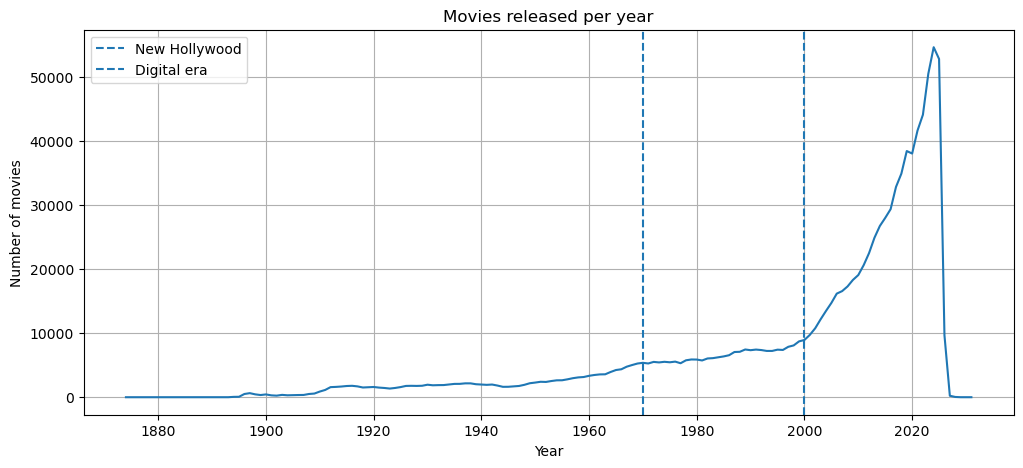

In [11]:
movies_per_year = df_movies['year'].value_counts().sort_index()

plt.figure(figsize=(12,5))
plt.plot(movies_per_year.index, movies_per_year.values)

plt.title("Movies released per year")
plt.xlabel("Year")
plt.ylabel("Number of movies")

plt.axvline(1970, linestyle="--", label="New Hollywood")
plt.axvline(2000, linestyle="--", label="Digital era")

plt.legend()
plt.grid(True)

plt.show()

The number of movies released per year increases slowly during the early 20th century as the film industry develops. Production grows more steadily after 1950 and accelerates after 2000, likely due to digital filmmaking and the expansion of the global movie industry.  

The drop in the most recent year is likely caused by **incomplete data** and is only due to 2026, as 2026 is not fully recorded in the dataset.

#### 2.2 Evolution of movie runtime

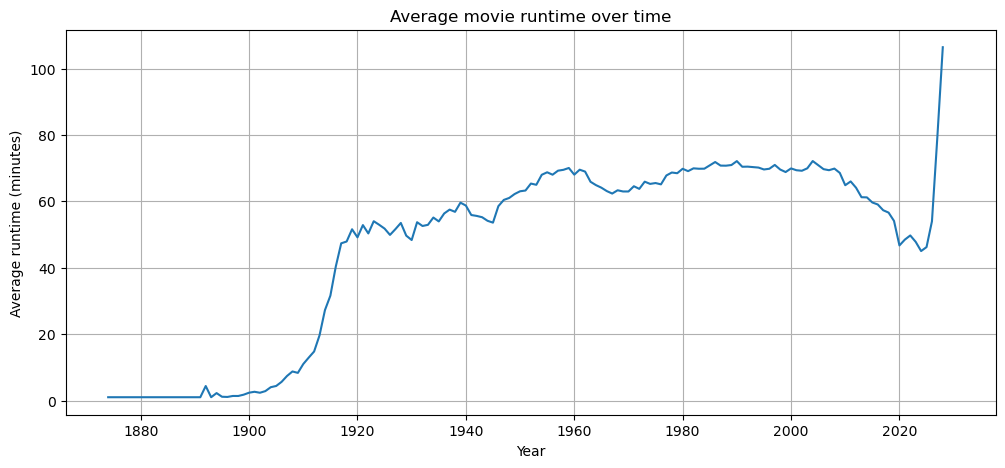

In [12]:
avg_runtime_year = df_movies.groupby('year')['runtime'].mean()

plt.figure(figsize=(12,5))
plt.plot(avg_runtime_year.index, avg_runtime_year.values)

plt.title("Average movie runtime over time")
plt.xlabel("Year")
plt.ylabel("Average runtime (minutes)")

plt.grid(True)
plt.show()

The average runtime of movies increases significantly during the early 20th century. We can see that early movies were very short, often only a few minutes long, but runtimes quickly grew as filmmaking techniques and storytelling developed.

From around the 1950s to the 2000s, the average runtime stabilizes at roughly 65–75 minutes. The sudden increase in the most recent years is likely due to **incomplete or irregular data** in the dataset rather than a real change in movie length.

#### 2.3 Avergage movie rating over time

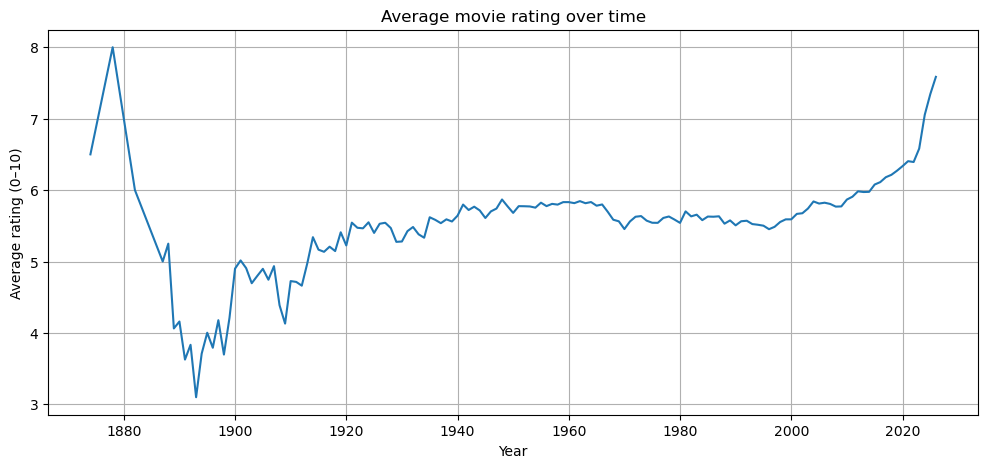

In [13]:
avg_rating_year = df_movies.groupby('year')['vote_average'].mean()

plt.figure(figsize=(12,5))
plt.plot(avg_rating_year.index, avg_rating_year.values)

plt.title("Average movie rating over time")
plt.xlabel("Year")
plt.ylabel("Average rating (0–10)")

plt.grid(True)
plt.show()

The average movie rating varies significantly in the early years of cinema because only a small number of movies were released each year, making the average more sensitive to individual ratings.

From around the 1920s to the 2000s, the average rating stabilizes between **5.5 and 5.9**, suggesting that the overall perceived quality of movies has remained relatively consistent over time.

In the most recent years, the average rating slightly increases.

#### 2.4 Evolution of genres

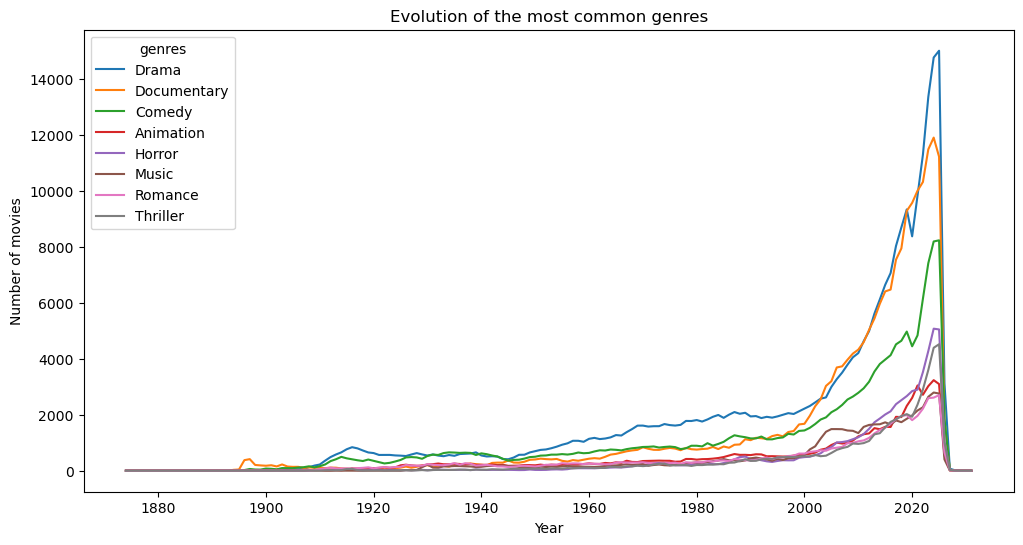

In [14]:
df_genres = df_movies.explode('genres')
genre_year = df_genres.groupby(['year', 'genres']).size().unstack(fill_value=0)
top_genres = df_genres['genres'].value_counts().head(8).index
genre_year_top = genre_year[top_genres]

plt.figure(figsize=(12,6))
genre_year_top.plot(ax=plt.gca())

plt.title("Evolution of the most common genres")
plt.xlabel("Year")
plt.ylabel("Number of movies")

plt.show()

In [15]:
start_of_genre = (
    df_genres.groupby('genres')['year'].min().sort_values().reset_index().rename(columns={'year': 'first year of appearance'}))

start_of_genre

,genres,first year of appearance
0,Documentary,1874.0
1,Animation,1878.0
2,Comedy,1892.0
3,Drama,1893.0
4,Action,1894.0
5,Romance,1894.0
6,Music,1894.0
7,Western,1894.0
8,Crime,1894.0
9,Science Fiction,1895.0


We can see that most major genres appeared very early in cinema history, mainly between **1870 and 1900**. 
Documentary appears as early as **1874**, Animation in **1878**, and other genres such as Comedy, Drama, Action, and Romance appear in the **1890s**, which reflects the rapid diversification of film themes shortly after the invention of cinema.

However, the graph shows that although these genres existed early, they **became significantly more prominent much later**, with the developpement of the movie industry. Throughout the first half of the 20th century, the number of movies in each genre remains relatively low. Starting around the **1950s**, production gradually increases, and from the **2000s onward** there is a sharp rise in the number of movies across most genres.

The table also shows that **TV Movies appear around 1930**, which corresponds to the early development of television technology. As television gradually spread, films began to be produced specifically for TV, marking a shift in how audiences consumed movies, with viewing moving from cinemas to home screens.

Genres such as **Drama and Comedy** dominate consistently over time, while others like **Horror, Thriller, and Animation** grow more noticeably in recent decades. This reflects the expansion of the global film industry, technological advances in filmmaking, and the diversification of audience preferences.

#### 2.5 Runtime evolution

**Note:** Some runtimes are clear outliers. For example, the dataset includes a 240-hour movie, which actually exists as an experimental film. To identify where extreme values begin, we examine the quartiles and the interquartile range (IQR). Based on this distribution, we choose an appropriate threshold to filter unrealistic runtimes for the analysis. We do a little pre-processing step to remove these.

In [16]:
Q1 = df_movies['runtime'].quantile(0.25)
Q3 = df_movies['runtime'].quantile(0.75)
IQR = Q3 - Q1

low_bound = Q1 - 1.5 * IQR
up_bound = Q3 + 1.5 * IQR

print("Q1:", Q1)
print("Q3:", Q3)
print("IQR:", IQR)
print("Lower bound:", low_bound)
print("Upper bound:", up_bound)

outliers = df_movies[(df_movies['runtime'] < low_bound) | (df_movies['runtime'] > up_bound)]
print("Number of runtime outliers:", len(outliers))

Q1: 13.0
Q3: 90.0
IQR: 77.0
Lower bound: -102.5
Upper bound: 205.5
Number of runtime outliers: 5478


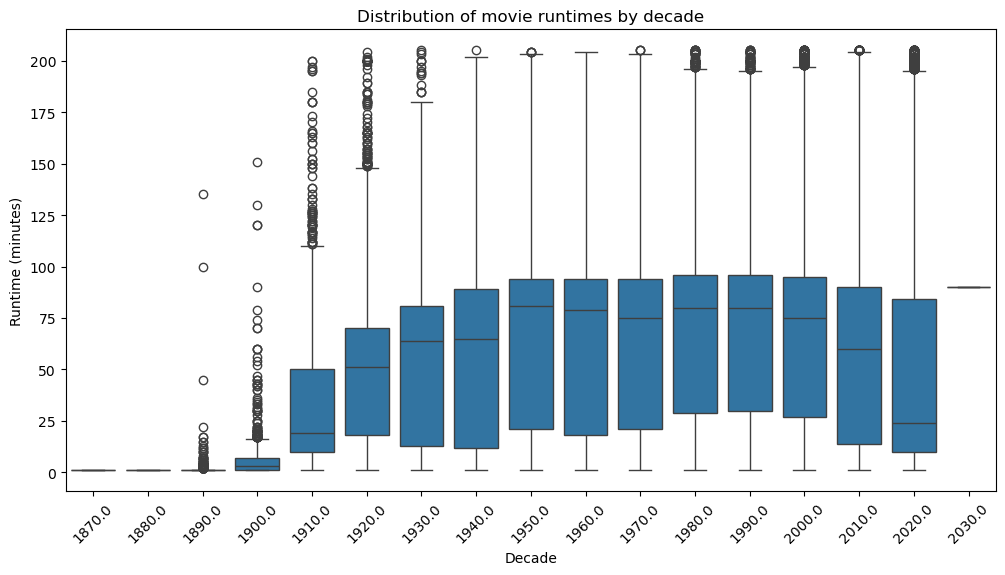

In [17]:
df_runtime = df_movies[(df_movies['runtime'] >= low_bound) & (df_movies['runtime'] <= up_bound)]

df_runtime['decade'] = (df_runtime['year'] // 10) * 10

plt.figure(figsize=(12,6))
sns.boxplot(x='decade', y='runtime', data=df_runtime)
plt.title("Distribution of movie runtimes by decade")
plt.xlabel("Decade")
plt.ylabel("Runtime (minutes)")
plt.xticks(rotation=45)

plt.show()

The above boxplot shows how the distribution of movie runtimes has evolved over time (after removing extreme outliers).

In the earliest decades of cinema (late 19th and early 20th century), films were extremely short, often only a few minutes long. Starting in the 1910s–1930s, runtimes increase significantly.

From roughly the **1950s onward**, most movies cluster between **70 and 100 minutes**, indicating the emergence of a standard duration. While some variation still exists, the median runtime remains relatively stable across modern decades.

We hence have a transition from **very short experimental films to standardized feature-length movies**. However, we can see that in the 2020s, although the overall distribution of runtimes remains similar across decades, we have a lower mean and median runtime. This is mainly due to the large number of short films and smaller productions included in recent datasets (increase of short format). 

In [18]:
"""
Run this code at the END of your milestone_1.ipynb after df_movies is defined.
It generates JSON files needed for your DataFlix website.
"""

import json
import pandas as pd
from pathlib import Path

# ==============================================================================
# 1. PRODUCTION DATA (Movies per year)
# ==============================================================================

production_data = df_movies.groupby('year').size().reset_index(name='count')
production_data = production_data[(production_data['year'] >= 1988) & (production_data['year'] <= 2025)]

production_json = [
    {'year': int(row['year']), 'count': int(row['count'])}
    for _, row in production_data.iterrows()
]

with open('production.json', 'w') as f:
    json.dump(production_json, f)

print("✓ production.json created")


# ==============================================================================
# 2. GENRE DATA (by decade)
# ==============================================================================

# Split genres if they're stored as strings (assuming comma-separated or list format)
df_genres = df_movies.copy()
df_genres['decade'] = (df_genres['year'] // 10) * 10

# If genres column contains lists/strings, parse them
if df_genres['genres'].dtype == 'object':
    # Try to handle it as JSON-like structure
    df_genres['genres_list'] = df_genres['genres'].apply(
        lambda x: x if isinstance(x, list) else (eval(x) if pd.notna(x) else [])
    )
else:
    df_genres['genres_list'] = df_genres['genres'].apply(lambda x: x if isinstance(x, list) else [])

# Expand genres to one row per genre
expanded_genres = []
for _, row in df_genres.iterrows():
    decade = row['decade']
    for genre in row['genres_list'][:1]:  # Take primary genre
        expanded_genres.append({'decade': decade, 'genre': genre})

genre_by_decade = pd.DataFrame(expanded_genres)
genre_counts = genre_by_decade.groupby(['decade', 'genre']).size().reset_index(name='count')

genre_json = []
for decade in sorted(genre_counts['decade'].unique()):
    decade_data = genre_counts[genre_counts['decade'] == decade]
    genre_json.append({
        'decade': int(decade),
        'genres': [
            {'name': row['genre'], 'count': int(row['count'])}
            for _, row in decade_data.iterrows()
        ]
    })

with open('genres.json', 'w') as f:
    json.dump(genre_json, f)

print("✓ genres.json created")


# ==============================================================================
# 3. RATINGS DATA (average ratings by year)
# ==============================================================================

df_ratings = df_movies[df_movies['vote_average'].notna()].copy()
ratings_by_year = df_ratings.groupby('year').agg({
    'vote_average': 'mean',
    'vote_count': 'count'
}).reset_index()
ratings_by_year.columns = ['year', 'avg_rating', 'count']
ratings_by_year = ratings_by_year[(ratings_by_year['year'] >= 1988) & (ratings_by_year['year'] <= 2025)]

ratings_json = [
    {
        'year': int(row['year']),
        'rating': round(float(row['avg_rating']), 2),
        'count': int(row['count'])
    }
    for _, row in ratings_by_year.iterrows()
]

with open('ratings.json', 'w') as f:
    json.dump(ratings_json, f)

print("✓ ratings.json created")


# ==============================================================================
# 4. FINANCE DATA (Budget vs Revenue)
# ==============================================================================

df_finance = df_movies[
    (df_movies['budget'].notna()) & 
    (df_movies['revenue'].notna()) & 
    (df_movies['budget'] > 0) & 
    (df_movies['revenue'] > 0)
].copy()

df_finance['decade'] = (df_finance['year'] // 10) * 10
df_finance['roi'] = ((df_finance['revenue'] - df_finance['budget']) / df_finance['budget'] * 100).round(2)

# Parse genres for finance data too
if df_finance['genres'].dtype == 'object':
    df_finance['genres_list'] = df_finance['genres'].apply(
        lambda x: x if isinstance(x, list) else (eval(x) if pd.notna(x) else [])
    )
else:
    df_finance['genres_list'] = df_finance['genres'].apply(lambda x: x if isinstance(x, list) else [])

finance_json = []
for _, row in df_finance.iterrows():
    try:
        finance_json.append({
            'title': str(row['title']) if pd.notna(row['title']) else 'Unknown',
            'budget': int(row['budget']) if pd.notna(row['budget']) else 0,
            'revenue': int(row['revenue']) if pd.notna(row['revenue']) else 0,
            'roi': float(row['roi']) if pd.notna(row['roi']) else 0,
            'year': int(row['year']) if pd.notna(row['year']) else 0,
            'decade': int(row['decade']) if pd.notna(row['decade']) else 0,
            'popularity': float(row['popularity']) if pd.notna(row['popularity']) else 0,
            'genre': row['genres_list'][0] if isinstance(row['genres_list'], list) and len(row['genres_list']) > 0 else 'Unknown'
        })
    except:
        pass  # Skip rows with conversion errors

with open('finance.json', 'w') as f:
    json.dump(finance_json, f)

print("✓ finance.json created")


# ==============================================================================
# 5. FEATURED MOVIES (one per era)
# ==============================================================================

df_featured = df_movies.copy()

# Parse genres for featured movies
if df_featured['genres'].dtype == 'object':
    df_featured['genres_list'] = df_featured['genres'].apply(
        lambda x: x if isinstance(x, list) else (eval(x) if pd.notna(x) else [])
    )
else:
    df_featured['genres_list'] = df_featured['genres'].apply(lambda x: x if isinstance(x, list) else [])

# Find best-rated movie from each era
movies_1990s = df_featured[(df_featured['year'] >= 1990) & (df_featured['year'] < 2000) & (df_featured['vote_average'].notna())]
movies_2000s = df_featured[(df_featured['year'] >= 2000) & (df_featured['year'] < 2010) & (df_featured['vote_average'].notna())]
movies_2010s = df_featured[(df_featured['year'] >= 2010) & (df_featured['year'] < 2020) & (df_featured['vote_average'].notna())]

featured_movies = []

if len(movies_1990s) > 0:
    movie = movies_1990s.nlargest(1, 'vote_average').iloc[0]
    featured_movies.append({
        'era': '1990s',
        'title': movie['title'],
        'genre': movie['genres_list'][0] if isinstance(movie['genres_list'], list) and len(movie['genres_list']) > 0 else 'Unknown',
        'rating': round(float(movie['vote_average']), 1),
        'revenue': int(movie['revenue']) if pd.notna(movie['revenue']) else 0,
        'year': int(movie['year'])
    })

if len(movies_2000s) > 0:
    movie = movies_2000s.nlargest(1, 'vote_average').iloc[0]
    featured_movies.append({
        'era': '2000s',
        'title': movie['title'],
        'genre': movie['genres_list'][0] if isinstance(movie['genres_list'], list) and len(movie['genres_list']) > 0 else 'Unknown',
        'rating': round(float(movie['vote_average']), 1),
        'revenue': int(movie['revenue']) if pd.notna(movie['revenue']) else 0,
        'year': int(movie['year'])
    })

if len(movies_2010s) > 0:
    movie = movies_2010s.nlargest(1, 'vote_average').iloc[0]
    featured_movies.append({
        'era': '2010s',
        'title': movie['title'],
        'genre': movie['genres_list'][0] if isinstance(movie['genres_list'], list) and len(movie['genres_list']) > 0 else 'Unknown',
        'rating': round(float(movie['vote_average']), 1),
        'revenue': int(movie['revenue']) if pd.notna(movie['revenue']) else 0,
        'year': int(movie['year'])
    })

with open('movies.json', 'w') as f:
    json.dump(featured_movies, f)

print("✓ movies.json created")


# ==============================================================================
# SUMMARY
# ==============================================================================

print("\n" + "="*60)
print("✓ ALL DATA FILES CREATED SUCCESSFULLY!")
print("="*60)
print("\nFiles created:")
print("  • production.json - Movies per year")
print("  • genres.json - Genre breakdown by decade")
print("  • ratings.json - Average ratings by year")
print("  • finance.json - Budget vs Revenue data")
print("  • movies.json - Featured movies per era")
print("\nNow follow the instructions below to place them in your website...")

✓ production.json created
✓ genres.json created
✓ ratings.json created
✓ finance.json created
✓ movies.json created

✓ ALL DATA FILES CREATED SUCCESSFULLY!

Files created:
  • production.json - Movies per year
  • genres.json - Genre breakdown by decade
  • ratings.json - Average ratings by year
  • finance.json - Budget vs Revenue data
  • movies.json - Featured movies per era

Now follow the instructions below to place them in your website...


In [ ]:
import json
import pandas as pd
import numpy as np
from pathlib import Path

# Create data folder
Path('data').mkdir(exist_ok=True)

# ==== 1. PRODUCTION DATA ====
production_data = df_movies.groupby('year').size().reset_index(name='count')
production_data = production_data[(production_data['year'] >= 1988) & (production_data['year'] <= 2025)].sort_values('year')
with open('data/production.json', 'w') as f:
    json.dump(production_data.to_dict('records'), f, indent=2)
print("✓ production.json")

# ==== 2. GENRE DATA ====
if isinstance(df_movies['genres'].iloc[0], str):
    df_movies['genres'] = df_movies['genres'].fillna("").apply(lambda x: [i.strip() for i in x.split(",") if i.strip()])
 
dg = df_movies[(df_movies['year'] >= 1988) & (df_movies['year'] <= 2025)].copy().explode('genres')
dg['decade'] = (dg['year'] // 10 * 10)  # ← NO .astype(str) - keep as integer
 
tg = dg['genres'].value_counts().head(12).index.tolist()
gdata = []
 
for dec in sorted(dg['decade'].unique()):
    gc = dg[dg['decade'] == dec]['genres'].value_counts()  # Both integer!
    gl = [{'name': g, 'count': int(gc.get(g, 0))} for g in tg if gc.get(g, 0) > 0]
    gdata.append({'decade': int(dec), 'genres': gl})
 
with open('data/genres.json', 'w') as f: 
    json.dump(gdata, f, indent=2)
 
print("✓ genres.json")

# ==== 3. RATINGS DATA ====
ratings_data = df_movies[(df_movies['year'] >= 1988) & (df_movies['year'] <= 2025)].groupby('year')['vote_average'].mean().reset_index(name='rating').dropna().sort_values('year')
with open('data/ratings.json', 'w') as f:
    json.dump(ratings_data.to_dict('records'), f, indent=2)
print("✓ ratings.json")

# ==== 4. FINANCE DATA ====
df_fin = df_movies[(df_movies['year'] >= 1988) & (df_movies['year'] <= 2025)].copy()
df_fin = df_fin.dropna(subset=['budget', 'revenue'])
df_fin = df_fin[(df_fin['budget'] > 0) & (df_fin['revenue'] > 0)]
df_fin['decade'] = (df_fin['year'] // 10 * 10)
df_fin['primary_genre'] = df_fin['genres'].apply(lambda x: x[0] if len(x) > 0 else 'Unknown')
finance_data = df_fin[['year', 'decade', 'title', 'budget', 'revenue', 'primary_genre', 'vote_average']].to_dict('records')[:1500]
with open('data/finance.json', 'w') as f:
    json.dump(finance_data, f, indent=2)
print("✓ finance.json")

# ==== 5. FEATURED MOVIES ====
movies_data = []
for start, end, era in [(1988, 1996, 'Late 80s'), (1996, 2006, '90s Blockbusters'), (2006, 2016, '2000s Digital'), (2016, 2026, '2010s-2020s')]:
    era_movies = df_movies[(df_movies['year'] >= start) & (df_movies['year'] < end) & (df_movies['revenue'] > 0) & (df_movies['vote_average'] > 6)].sort_values('vote_average', ascending=False)
    if len(era_movies) > 0:
        m = era_movies.iloc[0]
        movies_data.append({'title': str(m['title']), 'year': int(m['year']), 'era': era, 'genre': m['genres'][0] if len(m['genres']) > 0 else 'Drama', 'rating': float(m['vote_average']) if pd.notna(m['vote_average']) else 0, 'revenue': float(m['revenue']) if pd.notna(m['revenue']) else 0, 'budget': float(m['budget']) if pd.notna(m['budget']) else 0})
with open('data/movies.json', 'w') as f:
    json.dump(movies_data, f, indent=2)
print("✓ movies.json")

# ==== 6. INDEX.HTML ====
html = '''<!DOCTYPE html><html lang="en"><head><meta charset="UTF-8"/><meta name="viewport" content="width=device-width, initial-scale=1.0"/><title>DataFlix : The Evolution of Cinema</title><link rel="stylesheet" href="style.css"/></head><body><div class="timeline-progress"></div><header class="hero section-dark"><div class="hero-overlay"></div><nav class="navbar"><div class="logo">DataFlix</div><div class="nav-links"><a href="#production">Production</a><a href="#genres">Genres</a><a href="#ratings">Ratings</a><a href="#finance">Economy</a><a href="#movies">Movies</a></div></nav><div class="hero-inner"><div class="hero-left"><p class="eyebrow">A journey through film history</p><h1>The Evolution of Cinema</h1><p class="subtitle">Explore how cinema has transformed from 1988 to 2025 through production trends, genre shifts, audience reception, and financial dynamics.</p><div class="hero-actions"><a href="#production" class="cta primary">Start exploring</a><a href="#overview" class="cta secondary">Project overview</a></div></div><div class="hero-scroll-hint">Scroll to enter the timeline</div></header><main><section id="overview" class="section intro-section section-dark reveal"><div class="section-copy narrow"><p class="section-label">Introduction</p><h2>A story guided by time</h2><p>Cinema reflects technological progress, societal changes, and evolving audience preferences. Over the past four decades, the film industry has undergone major transformations: from the rise of blockbuster franchises to the emergence of streaming platforms, from the dominance of traditional genres to the explosion of diverse content.</p><p>Rather than presenting isolated charts, this project structures the data as a continuous journey. As you scroll through time, each section reveals a new dimension of cinema's evolution: how production volumes shifted, which genres captured audiences, how critical reception changed, and what the economics of filmmaking tell us about industry priorities.</p></div><div class="mini-timeline-card"><div class="mini-timeline-line"></div><div class="mini-node">1988</div><div class="mini-node">2000</div><div class="mini-node">2010</div><div class="mini-node">2025</div></div></section><section id="production" class="section split-section reveal stage-muted"><div class="section-copy"><p class="section-label">1. Production through time</p><h2>How has movie production evolved over time?</h2><p>Starting our journey in the late 1980s, we see how the volume of cinema production has shifted across decades. This visualization tracks the number of movies released each year, revealing growth patterns and fluctuations in the industry. Click on a genre below to filter the data and discover which genres drove production growth.</p><div class="controls" id="production-genres"><button class="chip active" data-genre="all">All genres</button></div></div><div class="viz-panel"><div class="viz-header"><h3>Movies released per year</h3><span class="badge">1988–2025</span></div><div class="chart-placeholder production-chart"></div></div></section><section id="genres" class="section split-section reveal stage-accent"><div class="viz-panel"><div class="viz-header"><h3>Genre composition over time</h3><span class="badge">Movies by genre per decade</span></div><div class="chart-placeholder genre-chart"></div></div><div class="section-copy"><p class="section-label">2. Genre evolution</p><h2>Which genres dominated different periods?</h2><p>Cinema's evolution is shaped by the genres that dominate each era. This visualization shows how different genres have grown (or declined) over time from 1988 to 2025. Each color represents a distinct genre, revealing which storytelling traditions have endured and which have emerged.</p><div class="legend" id="genre-legend"></div></div></section><section id="ratings" class="section split-section reveal stage-richer"><div class="section-copy"><p class="section-label">3. Audience reception over time</p><h2>How did audience reception change?</h2><p>More production doesn't necessarily mean better films. This line chart tracks average movie ratings over time, revealing whether quality has remained stable, improved, or declined as the industry scaled. The trend shows the tension between volume and artistic merit that defines modern cinema.</p></div><div class="viz-panel"><div class="viz-header"><h3>Average ratings by year</h3><span class="badge">1988–2025</span></div><div class="chart-placeholder ratings-chart"></div></div></section><section id="finance" class="section split-section reveal stage-richest"><div class="viz-panel"><div class="viz-header"><h3>Budget vs revenue by genre</h3><span class="badge">Scatter plot</span></div><div class="chart-placeholder finance-chart"></div></div><div class="section-copy"><p class="section-label">4. The economics of cinema</p><h2>How did financial dynamics evolve?</h2><p>The scale and risk profile of filmmaking has changed dramatically. This scatter plot reveals the relationship between production budgets and revenue across genres. Watch how blockbuster franchises dominate the high-budget, high-revenue corner, while smaller productions cluster in the lower left—each dot tells a story of investment and return.</p><div class="controls" id="finance-decades"><button class="chip active" data-decade="all">All decades</button><button class="chip" data-decade="1990">1990s</button><button class="chip" data-decade="2000">2000s</button><button class="chip" data-decade="2010">2010s</button></div></div></section><section id="movies" class="section reveal movies-section"><div class="section-copy centered"><p class="section-label">5. Representative films</p><h2>What films represent each era?</h2><p>Data reveals patterns, but cinema is ultimately about stories. This section showcases landmark films that defined their decades and shaped audience expectations.</p></div><div class="movie-strip" id="movie-strip"></div></section><section id="findings" class="section final-section reveal"><div class="section-copy centered narrow"><p class="section-label">6. Key insights</p><h2>Patterns that shaped cinema</h2><p>As we reach the end of this journey through cinema's evolution, several patterns emerge. These findings connect the dots between production, audience preference, and industry economics.</p></div><div class="findings-grid"><div class="finding-card"><span class="finding-number">01</span><h3>Production scaling</h3><p>Movie production has experienced significant growth, with notable peaks driven by specific genres dominating investment strategies.</p></div><div class="finding-card"><span class="finding-number">02</span><h3>Genre trajectories</h3><p>Traditional genres like drama remain stable, while action and visual-heavy genres show increasing investment over time.</p></div><div class="finding-card"><span class="finding-number">03</span><h3>Quality vs. quantity</h3><p>As production volume increases, audience ratings reveal whether the industry prioritizes volume or artistic merit.</p></div><div class="finding-card"><span class="finding-number">04</span><h3>Financial concentration</h3><p>Budgets and revenues show increasing concentration in blockbuster franchises, with most films in different risk profiles than earlier decades.</p></div></div><div class="closing-timeline"><span>1988</span><div class="closing-line"></div><span>2025</span></div></section></main><script src="script.js"></script></body></html>'''
with open('index.html', 'w') as f:
    f.write(html)
print("✓ index.html")

print("\n✅ ALL 5 JSON FILES + index.html CREATED!")
print("📁 Files in data/: production.json, genres.json, ratings.json, finance.json, movies.json")
print("\n📋 Still need to copy to same directory:")
print("   • style.css (from provided files)")
print("   • script.js (FIXED VERSION from provided files)")
print("\n🚀 Then run: python3 -m http.server 8000")

✓ production.json


ValueError: invalid literal for int() with base 10: '1980.0'